# taking all corrected objects dfs and combining them - and analyzing hallucination levels and wrong model extractions
## analyses that should appear here
### bar plots with objects that have all 3 categories to see how many validated objects we have and how many hallucinated objects ther are
### bar plots per participants to see if some hallucinate more than others|

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_1samp

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import pingouin as pg

In [2]:
#loading all data frames:
df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditinos_with_digit_span_w_object_hallucinations.csv")
# validated gpt data
gpt_df = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/gpt_trials_w_object_validation.csv")
#wilmas data from our extracted validated descriptions
df_wilma = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/wilmas_drawings_2019/nlp_analysis/wilma_descs_w_object_validation.csv")



# df_perc = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/10122025_pilot_2/nlp_analysis/ppt_trials_w_object_validation.csv")
# df_immediate = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/05012026_pilot_2_memory/nlp_analysis/ppt_trials_w_object_validation.csv")
# df_delay = pd.read_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/09032026_pilot_2_delayed_memory_digit-span/nlp_analysis/ppt_trials_w_object_validation.csv")

In [3]:
# df_perc["condition"] = "perception"
# df_immediate["condition"] = "immediate memory"
# df_delay["condition"] = "delayed memory"

In [4]:
# df = pd.concat([df_perc, df_immediate, df_delay], ignore_index=True)

In [5]:
# df.to_csv("/mnt/hdd/anatkorol/Imagination_in_translation/Data/processed_data/comparing_conditions/3_conditinos_with_digit_span_w_object_hallucinations.csv", index=False)

In [6]:
# using the clean df 
df = df[df['uid'] != 'qfd4qbm61773068899839']

In [7]:
df_wilma['condition']

0          perception
1          perception
2          perception
3          perception
4          perception
            ...      
107    delayed_memory
108    delayed_memory
109    delayed_memory
110    delayed_memory
111    delayed_memory
Name: condition, Length: 112, dtype: object

In [8]:

df_wilma = df.rename(columns={'delayed_memory': 'delayed memory', "immediate_memory": "immediate memory"})

In [9]:
selected_columns = ['uid', 'condition', 'gt', 'session', 'attempt', 'prompt', 'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object', 'n_invalid_not_in_image', 'diff_in_objects']

In [10]:
df[selected_columns].columns

Index(['uid', 'condition', 'gt', 'session', 'attempt', 'prompt',
       'validated_objects', 'invalid_not_objects', 'invalid_not_in_image',
       'n_extracted', 'n_validated', 'n_invalid_not_object',
       'n_invalid_not_in_image', 'diff_in_objects'],
      dtype='object')

# bar plots with objects, hallucinations and wrong model extractions

In [11]:
# Step 1: Sum the components for each individual attempt (per person)
# This handles cases where one attempt might have multiple rows/prompts
per_session = df.groupby(['uid', 'condition', 'attempt']).agg({
    'n_extracted': 'mean',
    'n_validated': 'mean',
    'n_invalid_not_object': 'mean',
    'n_invalid_not_in_image': 'mean'
}).reset_index()



# Step 2: Average these totals across all users (uids) for each condition/attempt
final_stats = per_session.groupby(['condition', 'attempt']).agg({
    'n_validated': 'mean',
    'n_invalid_not_object': 'mean',
    'n_invalid_not_in_image': 'mean',
    'n_extracted': 'mean'
}).reset_index()

In [12]:
final_stats

,condition,attempt,n_validated,n_invalid_not_object,n_invalid_not_in_image,n_extracted
0,delayed memory,1,3.720000,1.240000,0.280000,5.200000
1,delayed memory,2,4.120000,1.600000,0.400000,6.080000
2,delayed memory,3,4.480000,1.520000,0.480000,6.440000
3,immediate memory,1,4.700000,1.233333,0.500000,6.433333
4,immediate memory,2,5.033333,1.066667,0.466667,6.566667
5,immediate memory,3,4.966667,1.166667,0.266667,6.400000
6,perception,1,5.933333,1.566667,0.100000,7.600000
7,perception,2,6.566667,1.766667,0.100000,8.433333
8,perception,3,7.333333,1.466667,0.233333,9.033333


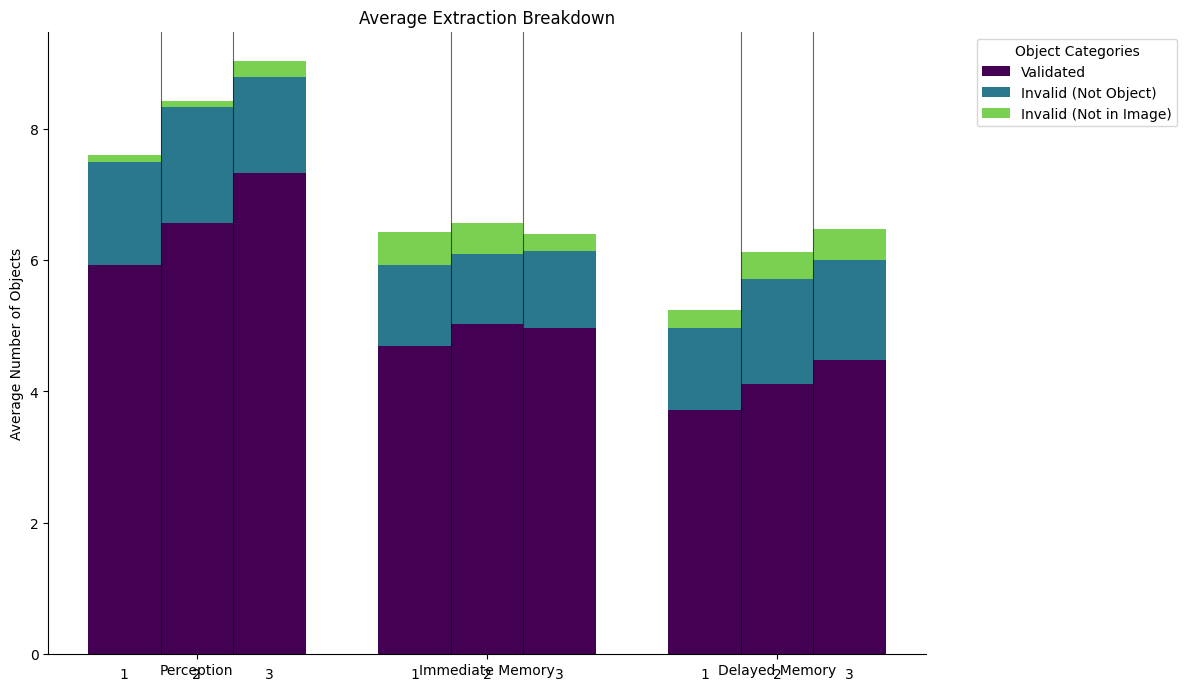

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Ensure these strings match your dataframe EXACTLY
conditions_order = ['perception', 'immediate memory', 'delayed memory']
attempts = [1, 2, 3]

# 2. Setup plotting dimensions
width = 0.25 
x = np.arange(len(conditions_order))
colors = plt.cm.viridis(np.linspace(0, 0.8, 3))
labels = ['Validated', 'Invalid (Not Object)', 'Invalid (Not in Image)']

fig, ax = plt.subplots(figsize=(12, 7))

for i, attempt in enumerate(attempts):
    # Filter for the attempt and reindex to force the specific order
    subset = final_stats[final_stats['attempt'] == attempt].set_index('condition').reindex(conditions_order).fillna(0)
    
    # Calculate horizontal position for attempt 1, 2, and 3
    pos = x + (i - 1) * width
    
    v = subset['n_validated'].values
    ino = subset['n_invalid_not_object'].values
    iii = subset['n_invalid_not_in_image'].values
    
    # Create the stacked bars
    ax.bar(pos, v, width, label=labels[0] if i == 0 else "", color=colors[0])
    ax.bar(pos, ino, width, bottom=v, label=labels[1] if i == 0 else "", color=colors[1])
    ax.bar(pos, iii, width, bottom=v+ino, label=labels[2] if i == 0 else "", color=colors[2])
    
    # Add simple '1', '2', '3' labels below each bar
    for j in range(len(conditions_order)):
        ax.text(pos[j], -0.2, str(attempt), ha='center', va='top', fontsize=10)

# 3. Add lines BETWEEN attempts within each condition group
for j in range(len(conditions_order)):
    # Line between Attempt 1 and 2
    ax.axvline(x=j - width/2, color='black', linewidth=0.8, linestyle='-', alpha=0.6)
    # Line between Attempt 2 and 3
    ax.axvline(x=j + width/2, color='black', linewidth=0.8, linestyle='-', alpha=0.6)

# 4. Final Formatting
ax.set_xticks(x)
ax.set_xticklabels([c.title() for c in conditions_order])
ax.set_ylabel('Average Number of Objects')
ax.set_title('Average Extraction Breakdown')
ax.legend(title="Object Categories", bbox_to_anchor=(1.05, 1), loc='upper left')

# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

# Bar plot for learning curve - object count progression - with validated and hallucinated objects. - per condition and attempt

### same graph but differnt appearance:

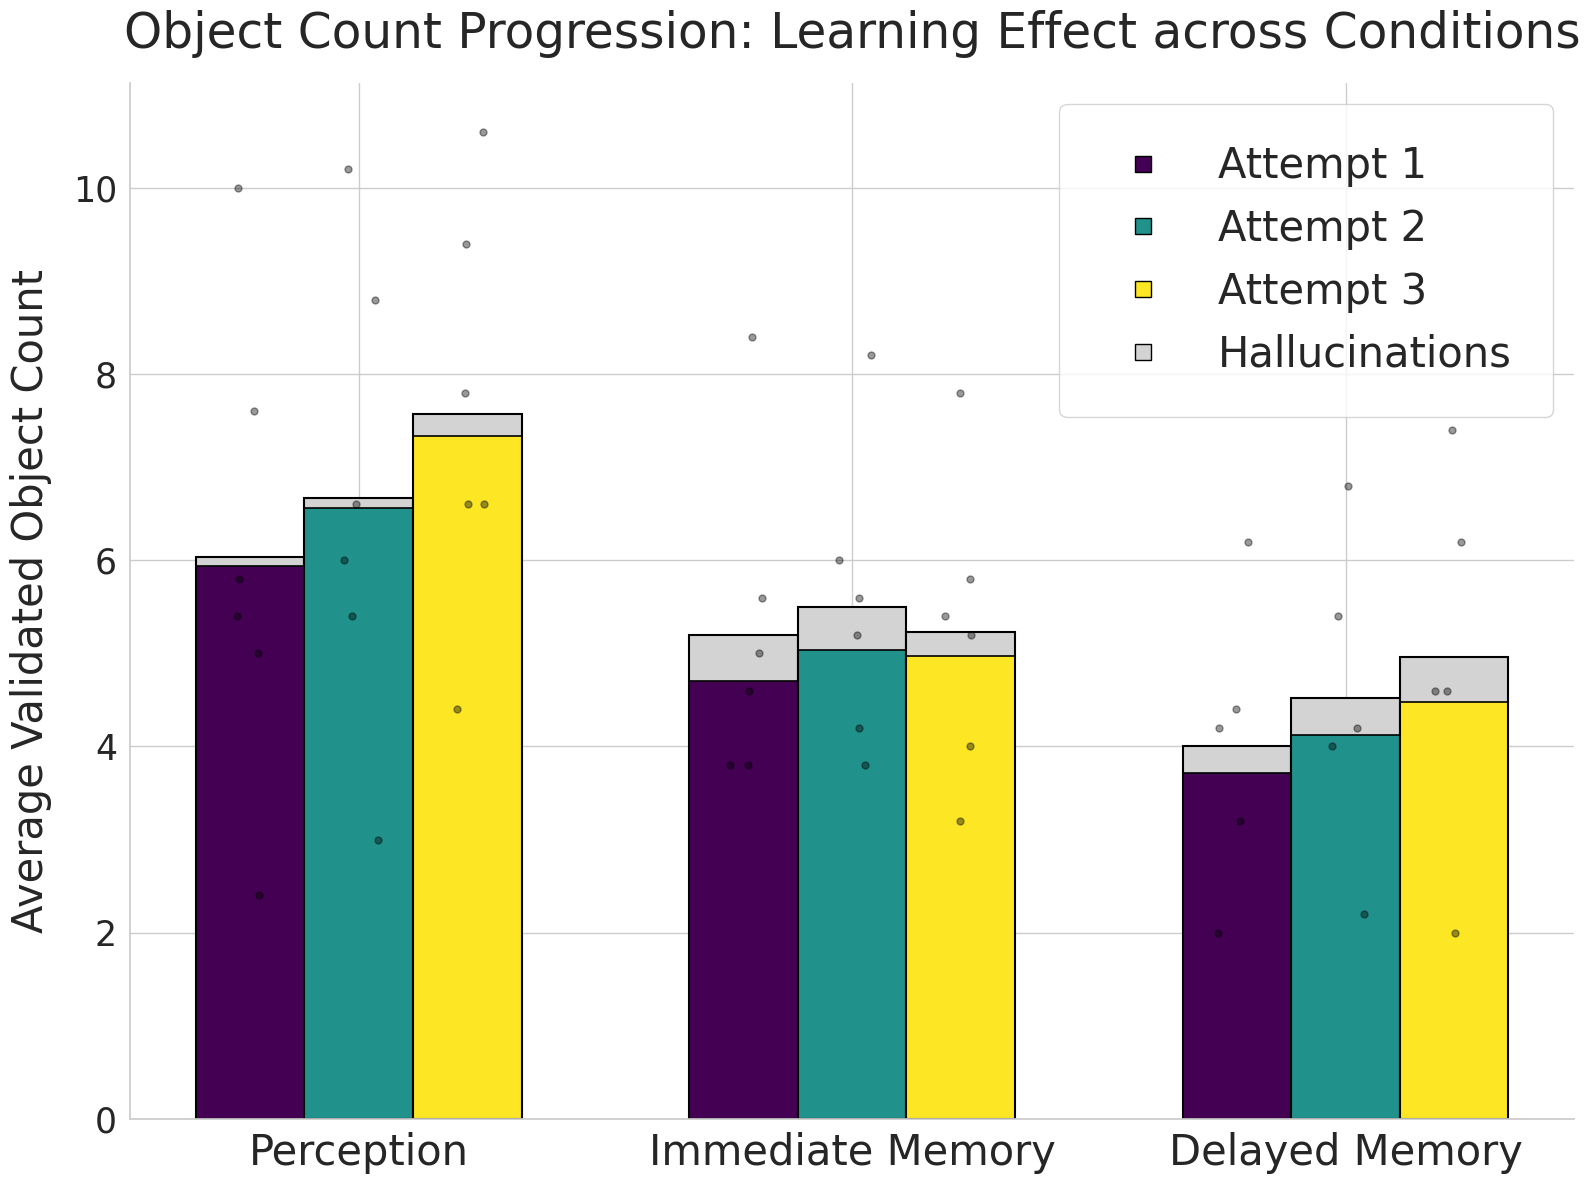

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.lines import Line2D

# 1. Aggregation: Get the average per user per condition per attempt
# This ensures the height of the bars matches the individual black dots' distribution
per_user_stats = df.groupby(['uid', 'condition', 'attempt']).agg({
    'n_validated': 'mean',
    'n_invalid_not_in_image': 'mean'
}).reset_index()

# Calculate the mean for the bars
final_stats = per_user_stats.groupby(['condition', 'attempt']).mean(numeric_only=True).reset_index()

# 1. Aggregation (Assuming df and per_user_stats are ready)
per_user_stats['total_extracted'] = per_user_stats['n_validated'] + per_user_stats['n_invalid_not_in_image']
final_stats = per_user_stats.groupby(['condition', 'attempt']).mean(numeric_only=True).reset_index()

# 2. Setup
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(16, 12))

conditions = ['perception', 'immediate memory', 'delayed memory']
attempts = [1, 2, 3]
width = 0.22 
x = np.arange(len(conditions))

attempt_colors = {1: '#440154', 2: '#21918c', 3: '#fde725'}
grey_color = '#d3d3d3'

# 3. Plotting Bars
for i, attempt in enumerate(attempts):
    subset = final_stats[final_stats['attempt'] == attempt].set_index('condition').reindex(conditions).fillna(0)
    pos = x + (i - 1) * width
    
    # Layer 1: Validated - REMOVED edgecolor to avoid the middle separation line
    ax.bar(pos, subset['n_validated'], width, 
           color=attempt_colors[attempt], 
           edgecolor='none') 
    
    # Layer 2: Hallucinations (Stacked) - edgecolor='black' but only for the outer boundary
    # We draw this with a zorder to ensure it sits correctly
    ax.bar(pos, subset['n_invalid_not_in_image'], width, 
           bottom=subset['n_validated'], 
           color=grey_color, 
           edgecolor='black', linewidth=1.2)
    
    # To get the black outline around the WHOLE bar without the middle line:
    # We draw an empty bar over the full height
    ax.bar(pos, subset['n_validated'] + subset['n_invalid_not_in_image'], width,
           fill=False, edgecolor='black', linewidth=1.5)

    # 4. LOWERED Attempt Numbers (1, 2, 3)
    # Adjusted 'y' to -0.8 and 'va' to top
    # for j in range(len(conditions)):
    #     ax.text(pos[j], -0.6, str(attempt), ha='center', va='top', fontsize=14, fontweight='bold')

# 5. Add Participant Variability Dots
for i, attempt in enumerate(attempts):
    for j, condition in enumerate(conditions):
        dot_data = per_user_stats[(per_user_stats['condition'] == condition) & 
                                  (per_user_stats['attempt'] == attempt)]
        bar_pos = j + (i - 1) * width
        x_jitter = np.random.uniform(-0.04, 0.04, size=len(dot_data))
        ax.scatter(bar_pos + x_jitter, dot_data['total_extracted'], 
                   color='black', alpha=0.4, s=25, zorder=3)

# 6. Final Polish
ax.set_title('Object Count Progression: Learning Effect across Conditions', fontsize=35, pad=25)
ax.set_ylabel('Average Validated Object Count', fontsize=30, labelpad=15)

ax.set_xticks(x)
ax.set_xticklabels([c.title() for c in conditions], fontsize=30)
plt.yticks(fontsize=25)

# Remove X label title
ax.xaxis.label.set_visible(False)

# 7. Legend (REVERTED to flat style, removed shadow)
legend_elements = [
    Line2D([0], [0], color=attempt_colors[1], lw=0, label='Attempt 1', marker='s', markeredgecolor='black', markersize=12, linestyle='None'),
    Line2D([0], [0], color=attempt_colors[2], lw=0, label='Attempt 2', marker='s', markeredgecolor='black', markersize=12, linestyle='None'),
    Line2D([0], [0], color=attempt_colors[3], lw=0, label='Attempt 3', marker='s', markeredgecolor='black', markersize=12, linestyle='None'),
    Line2D([0], [0], color=grey_color, lw=0, label='Hallucinations', marker='s', markeredgecolor='black', markersize=12, linestyle='None')
]

# Set shadow=False for the previous flat look
ax.legend(handles=legend_elements, loc='upper right', fontsize=30, frameon=True, shadow=False, borderpad=1)

sns.despine()
plt.tight_layout()
plt.show()

## comparison with wilma and chat gpt descriptions

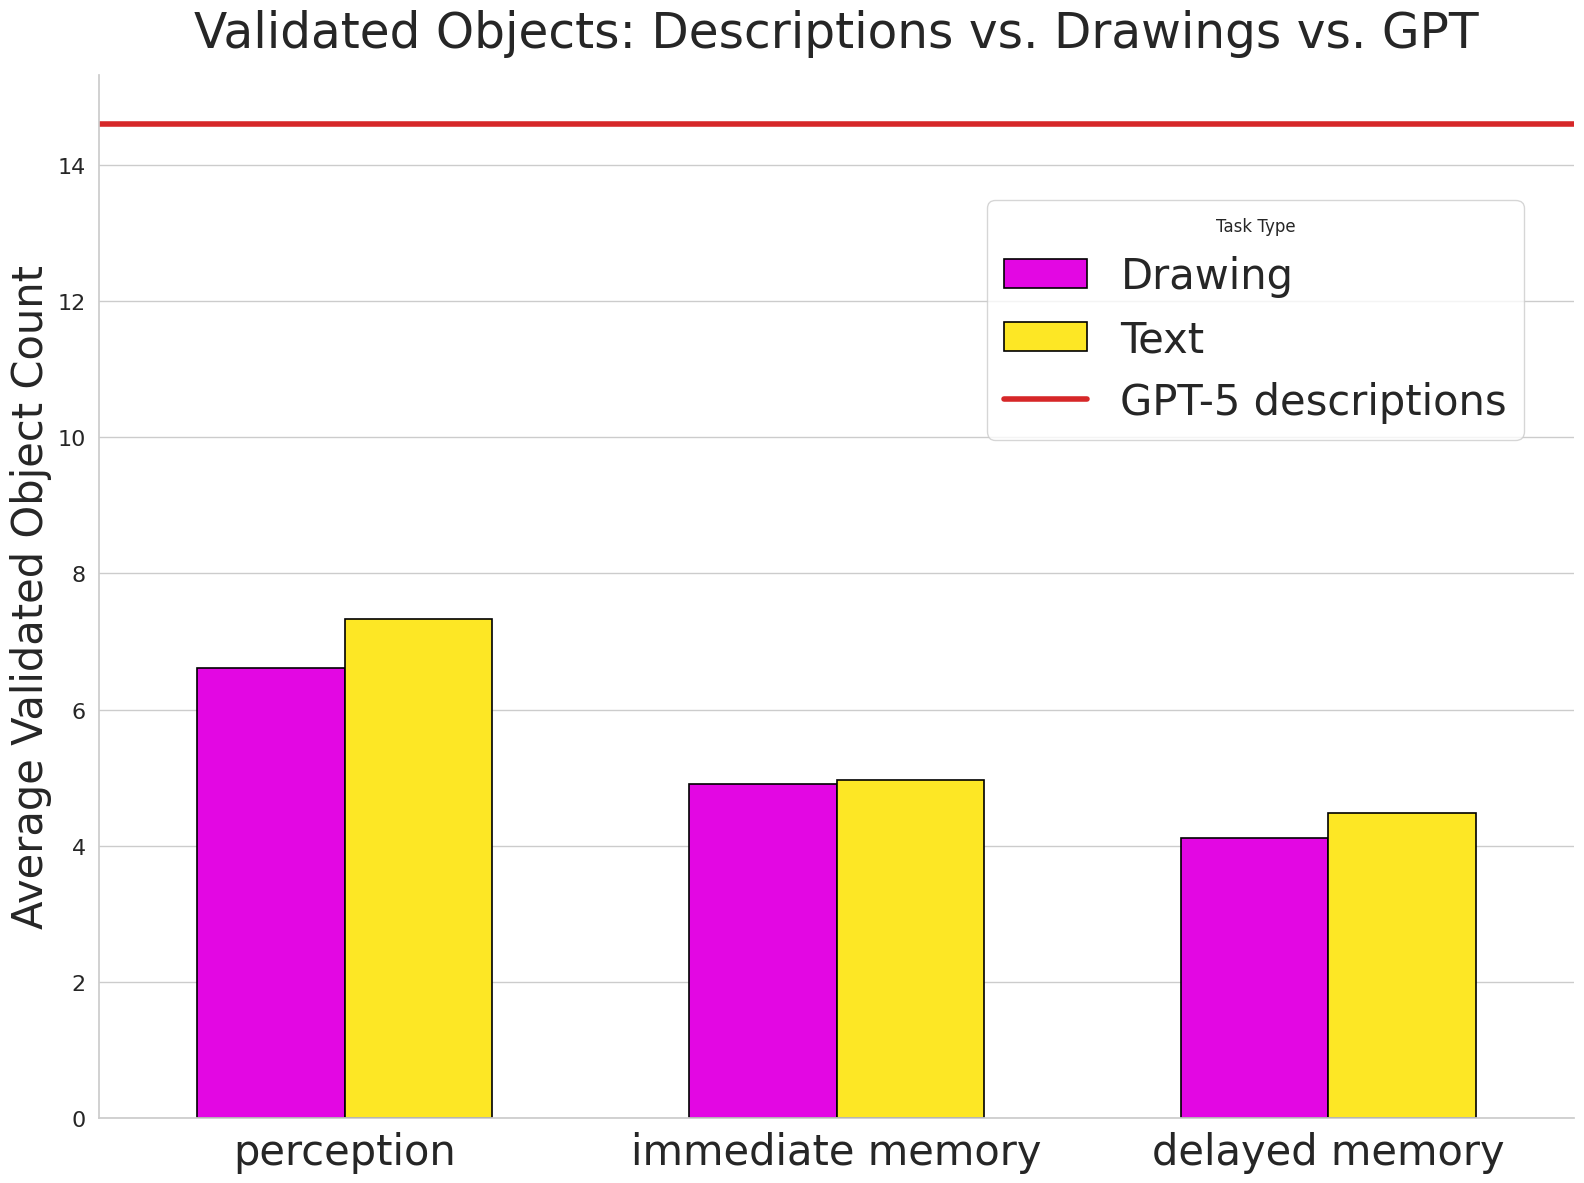

In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Prepare your data (average across all attempts/uids)
# 1. Prepare human data: Filter for the 3rd attempt, then average by condition
human_avg = df[df['attempt'] == 3].groupby('condition')['n_validated'].mean().reset_index()

# Labeling for the comparison plot
human_avg['Source'] = 'Text' 
human_avg.rename(columns={'n_validated': 'count'}, inplace=True)


# 2. Prepare Wilma data (assuming it has 'condition' and 'n_validated')
wilma_avg = df_wilma.groupby('condition')['n_validated'].mean().reset_index()
wilma_avg['Source'] = 'Drawing'
wilma_avg.rename(columns={'n_validated': 'count'}, inplace=True)

# Combine for plotting
comparison_df = pd.concat([wilma_avg, human_avg])
condition_order = ['perception', 'immediate memory', 'delayed memory']

# 3. GPT Value
gpt_val = gpt_df['n_validated'].mean()

# 4. Plotting
plt.figure(figsize=(16, 12))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    data=comparison_df,
    x='condition',
    y='count',
    hue='Source',
    order=condition_order,
    palette=["#E307E3", '#fde725'], # Purple for Wilma/Descriptions, Yellow for Human/Drawings
    alpha=1,
    saturation=1,
    errorbar=None,
    width=0.6,
    edgecolor='black',
    linewidth=1.2
)

# 5. Add the GPT red line across the whole figure
ax.axhline(y=gpt_val, color='#d62728', linestyle='-', linewidth=4, label='GPT-5 descriptions', zorder=0)

# 6. Final Polish
plt.title('Validated Objects: Descriptions vs. Drawings vs. GPT', fontsize=35, pad=20)
plt.ylabel('Average Validated Object Count', fontsize=30)
plt.xlabel('', fontsize=0) # Removed label as per previous style
plt.xticks(fontsize=30)
plt.yticks(fontsize=16)

# Handle Legend
# Lowering the legend by changing the second value from 1 to 0.9 or 0.8
plt.legend(
    title='Task Type', 
    loc='upper right', 
    bbox_to_anchor=(0.98, 0.9), # Adjust 0.9 to move it further down
    fontsize=30,
    frameon=True
)
sns.despine()
plt.tight_layout()
plt.show()

# drawings only data

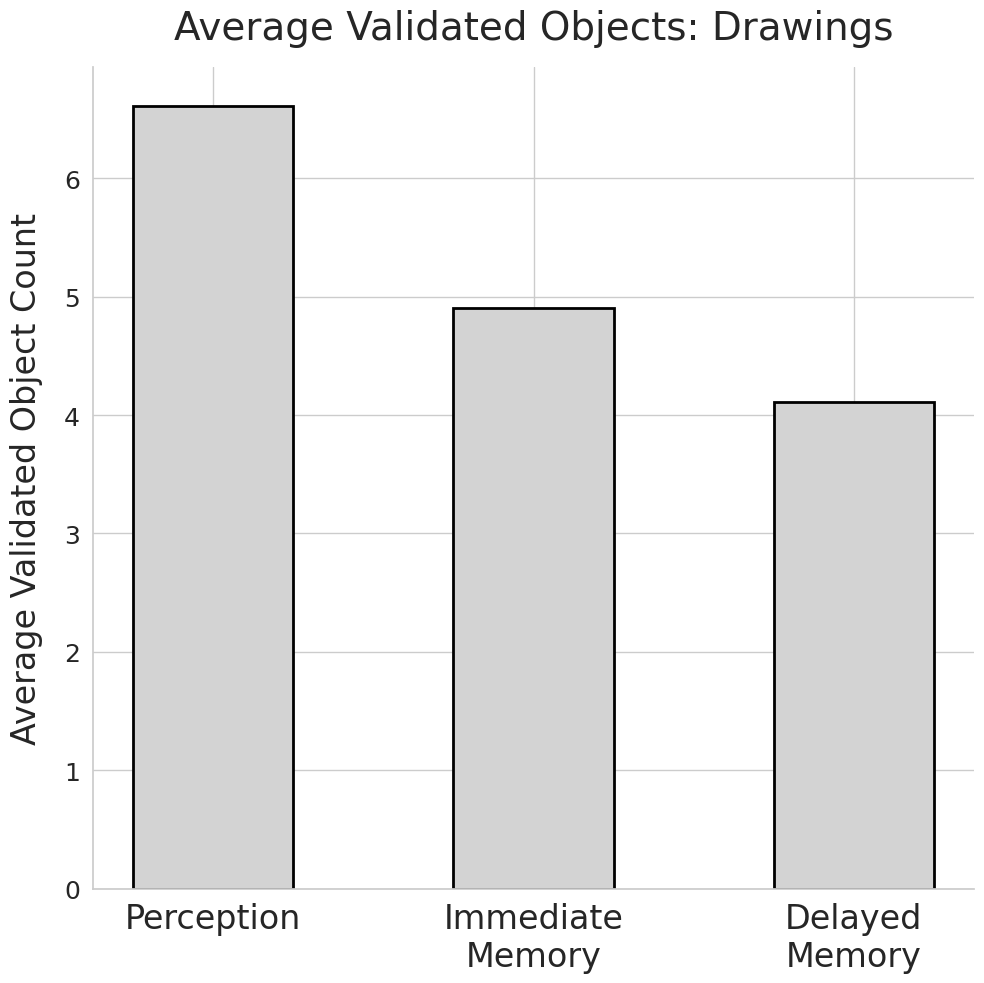

In [16]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# --- 1. Data Aggregation ---
draw_stats = df_wilma.groupby(['condition'])['n_validated'].mean().reset_index()

conditions = ['perception', 'immediate memory', 'delayed memory']
draw_stats['condition'] = pd.Categorical(draw_stats['condition'], categories=conditions, ordered=True)
draw_stats = draw_stats.sort_values('condition')

# --- 2. Setup Plotting ---
sns.set_theme(style="whitegrid")
# Reduced width from 12 to 8 for a narrower profile
fig, ax = plt.subplots(figsize=(10, 10))

draw_color = '#d3d3d3' 

# --- 3. Plotting ---
# We use draw_stats['condition'] but we will format the labels in the next step
bars = ax.bar(
    draw_stats['condition'], 
    draw_stats['n_validated'], 
    color=draw_color, 
    edgecolor='black', 
    linewidth=2,
    width=0.5 # Slightly wider bar for the narrower figure
)

# --- 4. Final Polish ---
ax.set_title('Average Validated Objects: Drawings', fontsize=28, pad=20)
ax.set_ylabel('Average Validated Object Count', fontsize=24, labelpad=15)

# X-axis formatting: Replace space with \n and capitalize
# This forces "Immediate Memory" to "Immediate\nMemory"
formatted_labels = [c.title().replace(' ', '\n') for c in conditions]
ax.set_xticks(range(len(conditions)))
ax.set_xticklabels(formatted_labels, fontsize=24)

plt.yticks(fontsize=18)
ax.xaxis.label.set_visible(False)

sns.despine()
plt.tight_layout()
plt.show()

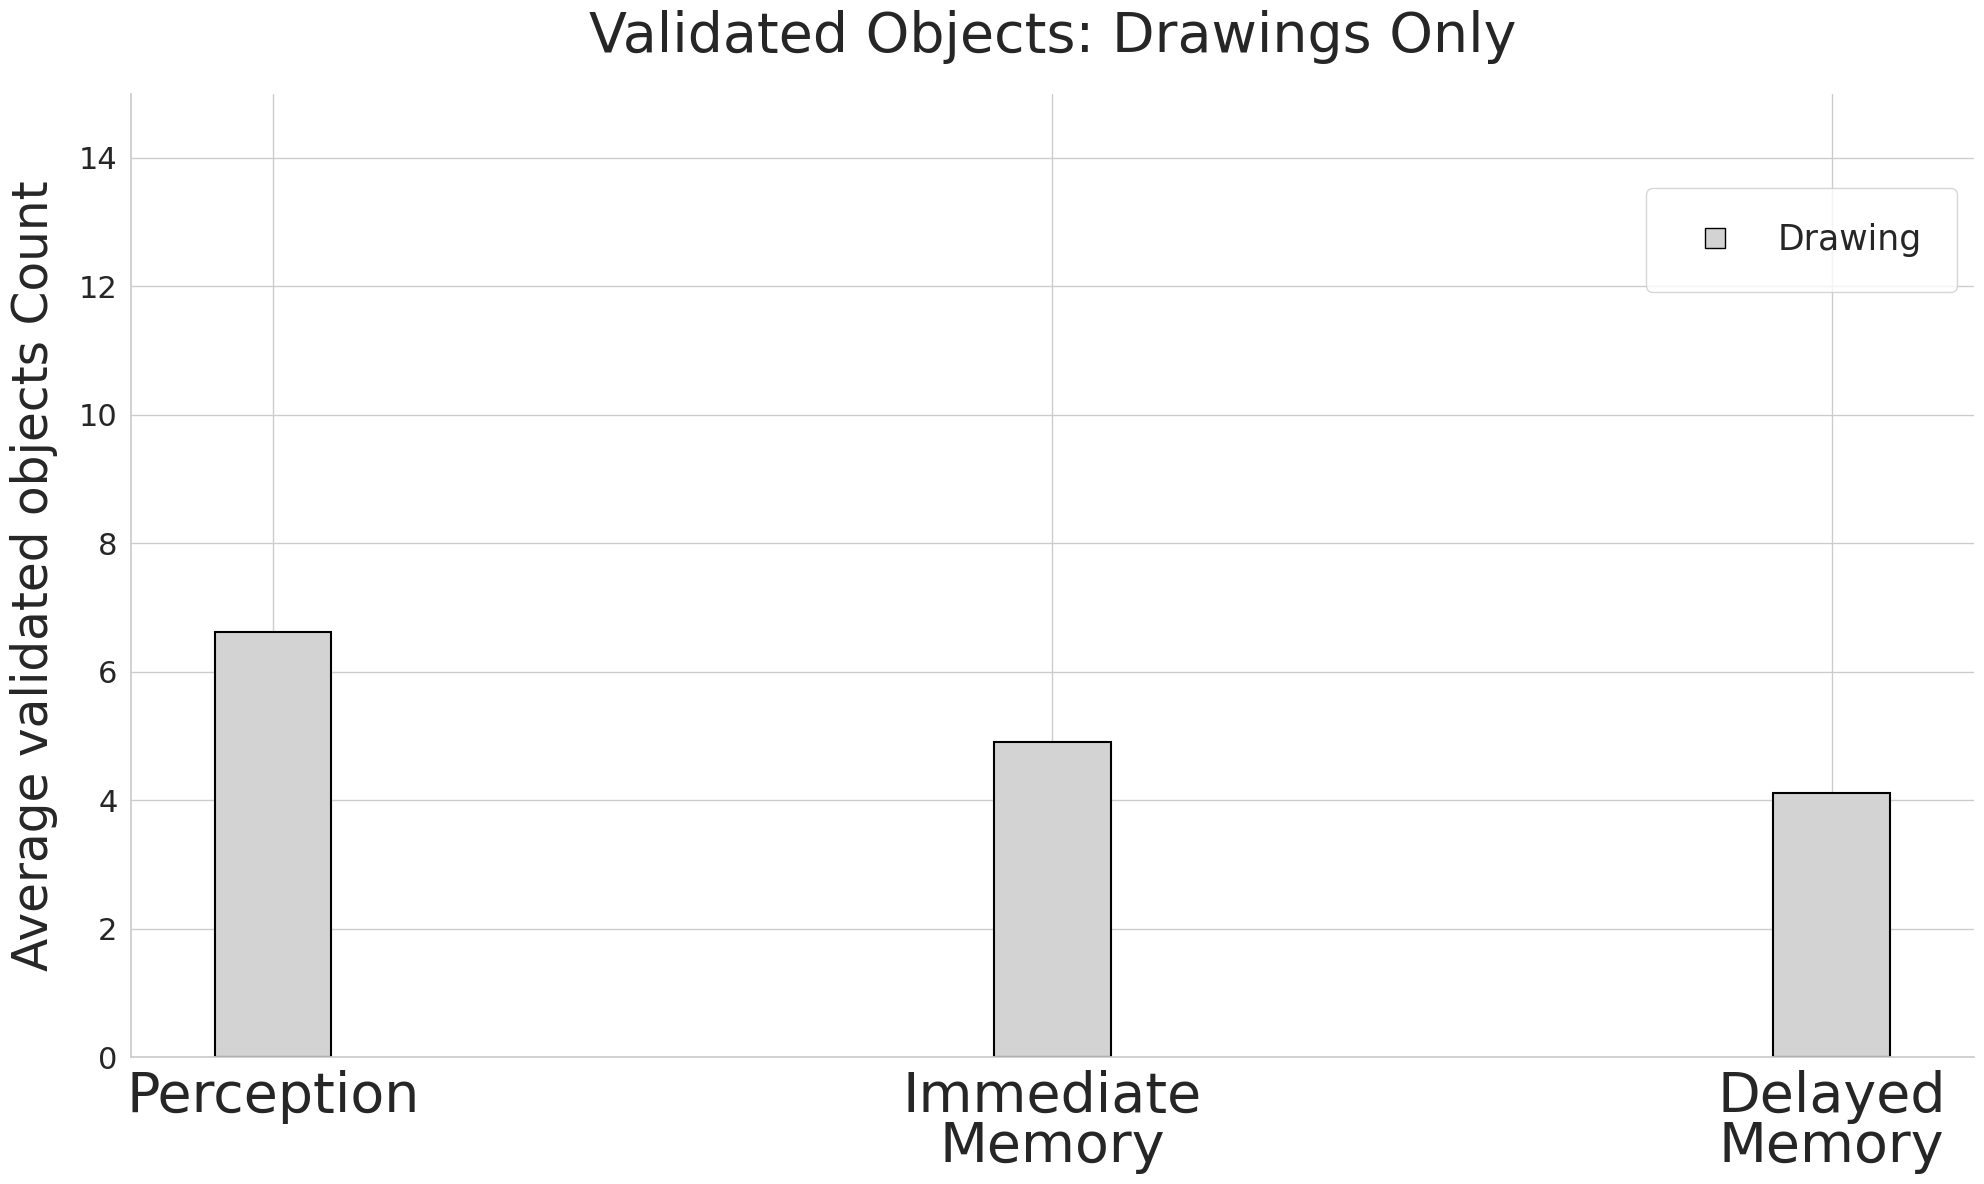

In [44]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

# --- 1. Data Aggregation (Keep logic identical for scaling) ---
per_user_desc = df.groupby(['uid', 'condition', 'attempt']).agg({
    'n_validated': 'mean',
    'n_invalid_not_in_image': 'mean'
}).reset_index()
per_user_desc['total'] = per_user_desc['n_validated'] + per_user_desc['n_invalid_not_in_image']

per_user_draw = df_wilma.groupby(['uid', 'condition']).agg({
    'n_validated': 'mean'
}).reset_index()

desc_stats = per_user_desc.groupby(['condition', 'attempt']).mean(numeric_only=True).reset_index()
draw_stats = per_user_draw.groupby(['condition']).mean(numeric_only=True).reset_index()
gpt_val = gpt_df['n_validated'].mean()

# --- 2. Setup Plotting ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(20, 12))

conditions = ['perception', 'immediate memory', 'delayed memory']
attempts = [1, 2, 3]
x = np.arange(len(conditions))
width = 0.15 

draw_color = '#d3d3d3' 
blue_palette = ['#a1c9f4', '#4878d0', '#1c335e'] 

# --- 3. Plotting Bars ---

for j, condition in enumerate(conditions):
    # --- A. Drawing Bar (Keep this) ---
    pos_draw = j - 1.5 * width
    draw_val = draw_stats[draw_stats['condition'] == condition]['n_validated'].values[0]
    
    ax.bar(pos_draw, draw_val, width, color=draw_color, edgecolor='black', linewidth=1.5)
    
    # Optional: Dots for Drawings (Uncomment if you want them visible on this slide)
    # dots_draw = per_user_draw[per_user_draw['condition'] == condition]['n_validated']
    # ax.scatter(np.random.uniform(pos_draw-0.03, pos_draw+0.03, len(dots_draw)), dots_draw, 
    #            color='black', alpha=0.3, s=25, zorder=3)

    # --- B. Description Attempt Bars (Hidden to keep alignment) ---
    for i, attempt in enumerate(attempts):
        # We calculate the position but don't call ax.bar() 
        # This ensures the 'Drawing' bar doesn't shift to the center
        pos_desc = j + (i - 0.5) * width

# --- 4. Final Polish ---

# Keep GPT Baseline for context (or comment out if you want it strictly for drawings)
# ax.axhline(y=gpt_val, color='#d62728', linestyle='--', linewidth=3, label='GPT-5 Baseline', zorder=2)

ax.set_title('Validated Objects: Drawings Only', fontsize=40, pad=30)
ax.set_ylabel('Average validated objects Count', fontsize=35, labelpad=15)
# 1. Prepare the wrapped labels
wrapped_labels = [c.title().replace(' ', '\n') for c in conditions]

# 2. Apply them to the axis
# Center the ticks on the drawing bars instead of the group center
ax.set_xticks(x - 1.5 * width) 


ax.set_xticklabels(wrapped_labels, fontsize=40, linespacing=0.9)
# Set ticks every 2 units from 0 to 14
ax.set_yticks(np.arange(0, 15, 2))

# Ensure the font size remains consistent with your previous graph
ax.tick_params(axis='y', labelsize=22)

# Set the limit to 14 (or slightly higher, like 15, to give the bars some head room)
ax.set_ylim(0, 15)


# Set Y-axis limit identical to the first graph to prevent jumping during transition
# Replace 'MAX_Y_VALUE' with the height of your highest description bar from the original data
# ax.set_ylim(0, MAX_Y_VALUE) 

# Minimal Legend for this version
legend_elements = [
    Line2D([0], [0], color=draw_color, lw=0, label='Drawing', marker='s', markeredgecolor='black', markersize=15),
    # Line2D([0], [0], color='#d62728', lw=3, linestyle='--', label='GPT-5 Baseline')
]

ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 0.92), fontsize=25, frameon=True, borderpad=1)

sns.despine()
plt.tight_layout()
plt.show()

# combined plot - for drawings and all attempts of descriptions

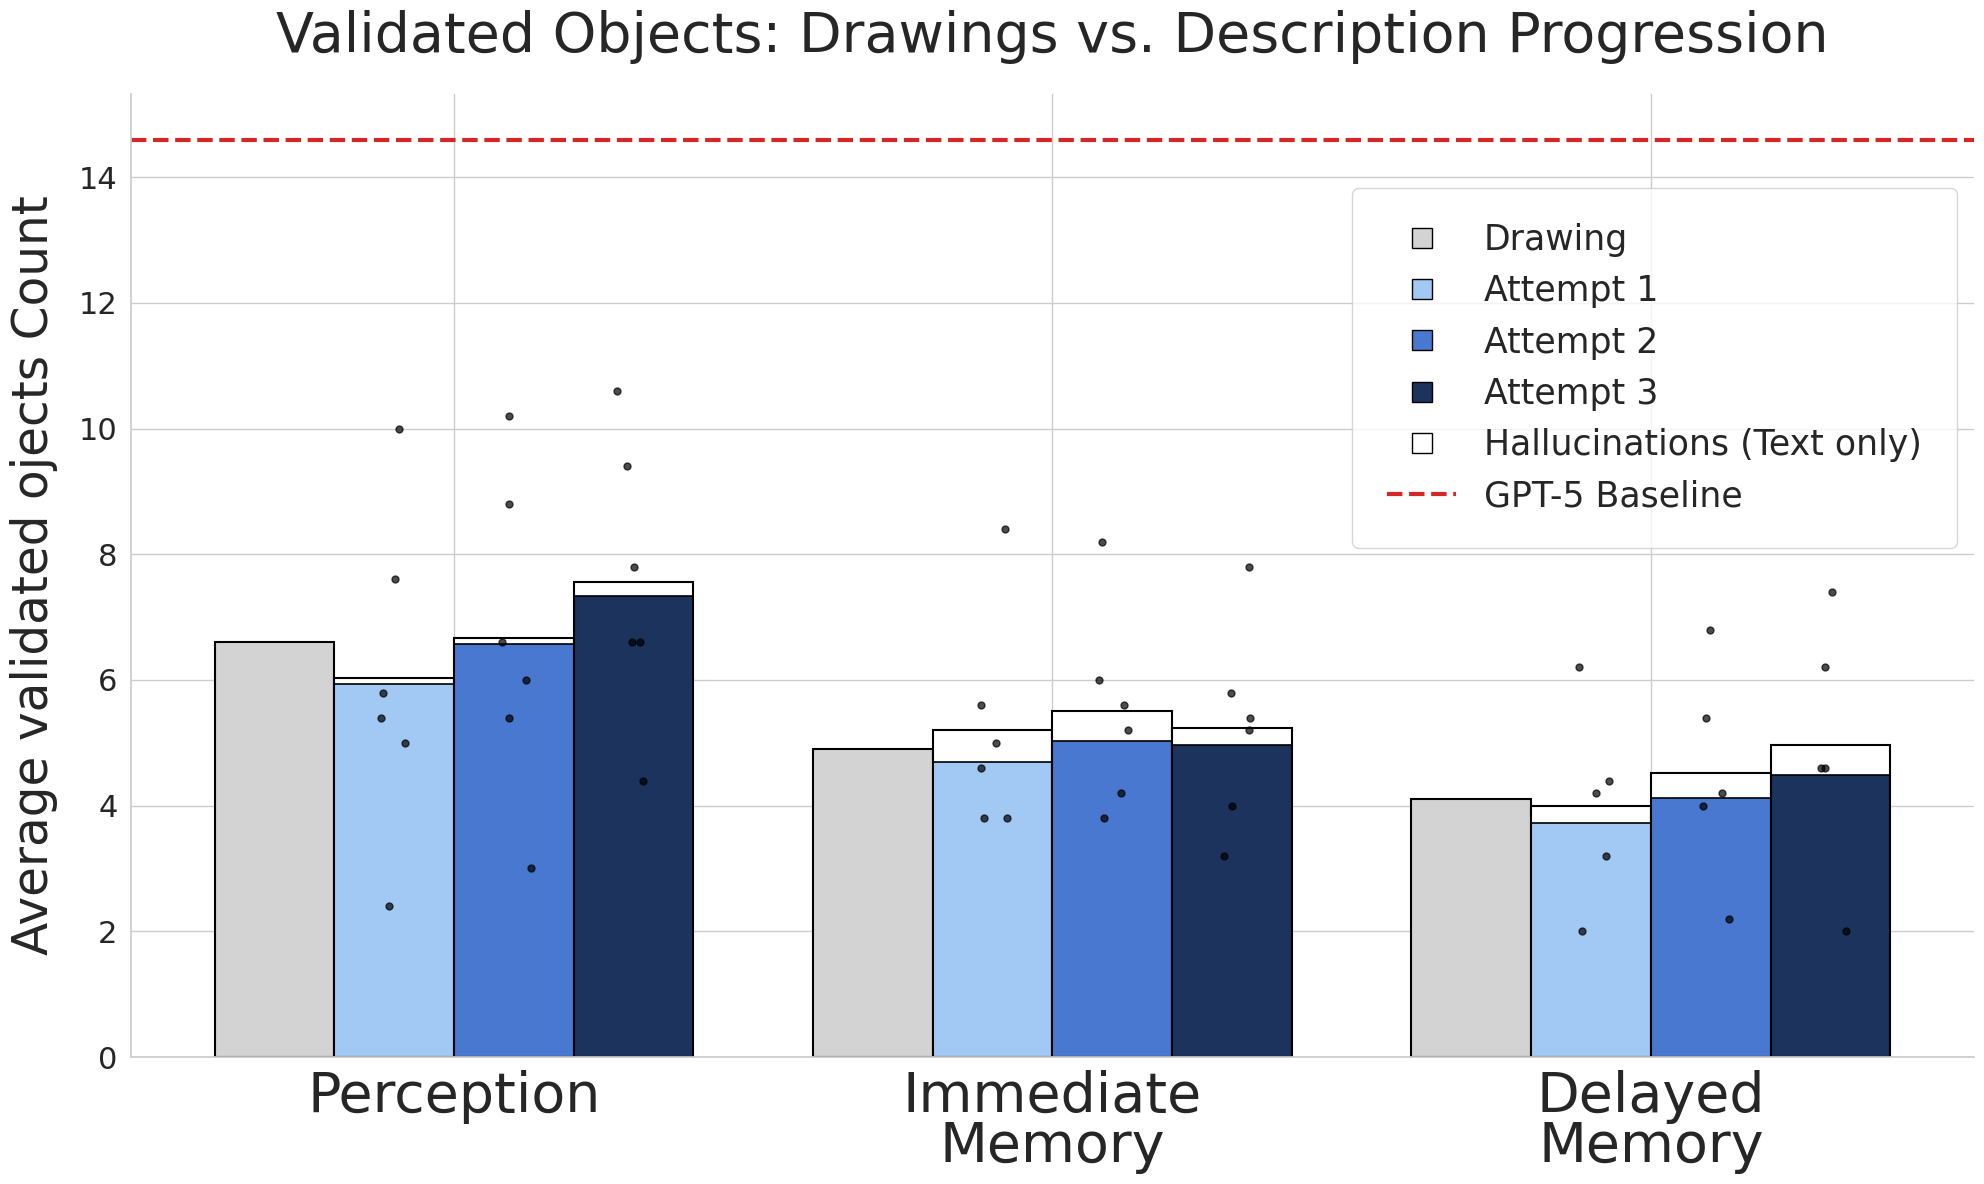

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D

# --- 1. Data Aggregation ---

# A. Descriptions Data (Keep validated + hallucinations)
per_user_desc = df.groupby(['uid', 'condition', 'attempt']).agg({
    'n_validated': 'mean',
    'n_invalid_not_in_image': 'mean'
}).reset_index()
per_user_desc['total'] = per_user_desc['n_validated'] + per_user_desc['n_invalid_not_in_image']

# B. Drawings Data (Validated ONLY - no hallucinations)
per_user_draw = df_wilma.groupby(['uid', 'condition']).agg({
    'n_validated': 'mean'
}).reset_index()

# C. Means for Bars
desc_stats = per_user_desc.groupby(['condition', 'attempt']).mean(numeric_only=True).reset_index()
# draw_stats = per_user_draw.groupby(['condition']).mean(numeric_only=True).reset_index()

# D. GPT Value
gpt_val = gpt_df['n_validated'].mean()

# --- 2. Setup Plotting ---
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(figsize=(20, 12))

conditions = ['perception', 'immediate memory', 'delayed memory']
attempts = [1, 2, 3]
x = np.arange(len(conditions))
width = 0.2 

# Colors
# draw_color = '#d3d3d3'          # Grey for Drawings
blue_palette = ['#a1c9f4', '#4878d0', '#1c335e'] # Blues for Desc
pink_hallucination = "#ffffff"  # Pink for Desc hallucinations

# --- 3. Plotting Bars ---

for j, condition in enumerate(conditions):
    # --- A. Drawing Bar (Single Solid Grey Bar) ---
    pos_draw = j - 1.5 * width
    draw_val = draw_stats[draw_stats['condition'] == condition]['n_validated'].values[0]
    
    ax.bar(pos_draw, draw_val, width, color=draw_color, edgecolor='black', linewidth=1.5)
    
    # Dots for Drawings
    # dots_draw = per_user_draw[per_user_draw['condition'] == condition]['n_validated']
    # ax.scatter(np.random.uniform(pos_draw-0.03, pos_draw+0.03, len(dots_draw)), dots_draw, 
    #            color='black', alpha=0.3, s=25, zorder=3)

    # --- B. Description Attempt Bars (Stacked with Pink) ---
    for i, attempt in enumerate(attempts):
        pos_desc = j + (i - 0.5) * width
        subset = desc_stats[(desc_stats['condition'] == condition) & (desc_stats['attempt'] == attempt)]
        
        val = subset['n_validated'].values[0]
        hal = subset['n_invalid_not_in_image'].values[0]
        
        # Validated base
        ax.bar(pos_desc, val, width, color=blue_palette[i], edgecolor='none')
        # Hallucination stack (Pink)
        ax.bar(pos_desc, hal, width, bottom=val, color=pink_hallucination, edgecolor='black', linewidth=1.2)
        # Outline for the whole stack
        ax.bar(pos_desc, val + hal, width, fill=False, edgecolor='black', linewidth=1.5)
        
        # Dots for Descriptions (showing total height)
        dots_desc = per_user_desc[(per_user_desc['condition'] == condition) & 
                                 (per_user_desc['attempt'] == attempt)]['total']
        ax.scatter(np.random.uniform(pos_desc-0.03, pos_desc+0.03, len(dots_desc)), dots_desc, 
                   color='black', alpha=0.7, s=25, zorder=3)

# --- 4. Final Polish ---

ax.axhline(y=gpt_val, color='#d62728', linestyle='--', linewidth=3, label='GPT-5 Baseline', zorder=2)

ax.set_title('Validated Objects: Drawings vs. Description Progression', fontsize=40, pad=30)
ax.set_ylabel('Average validated ojects Count', fontsize=35, labelpad=15)
wrapped_labels = [c.title().replace(' ', '\n') for c in conditions]

# 2. Apply them to the axis
ax.set_xticks(x)
ax.set_xticklabels(wrapped_labels, fontsize=40, linespacing=0.9)
plt.yticks(fontsize=22)

# Custom Legend
legend_elements = [
    Line2D([0], [0], color=draw_color, lw=0, label='Drawing', marker='s', markeredgecolor='black', markersize=15),
    Line2D([0], [0], color=blue_palette[0], lw=0, label='Attempt 1', marker='s', markeredgecolor='black', markersize=15),
    Line2D([0], [0], color=blue_palette[1], lw=0, label='Attempt 2', marker='s', markeredgecolor='black', markersize=15),
    Line2D([0], [0], color=blue_palette[2], lw=0, label='Attempt 3', marker='s', markeredgecolor='black', markersize=15),
    Line2D([0], [0], color=pink_hallucination, lw=0, label='Hallucinations (Text only)', marker='s', markeredgecolor='black', markersize=15),
    Line2D([0], [0], color='#d62728', lw=3, linestyle='--', label='GPT-5 Baseline')
]

ax.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 0.92), fontsize=25, frameon=True, borderpad=1)

sns.despine()
plt.tight_layout()
plt.show()